In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [3]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [4]:
def initialize_with_zeros(dim):       # w should be a vector of (dimension of image --> height x width x colour channel, 1)
  w = np.zeros(shape=(dim,1))
  b = 0                               #literally just a constant lmao
  return w,b

In [5]:
def propogate(w,b,X,Y):                       # X is input feature and Y is label for cat or not(0 or 1)
  m = X.shape[1]                              #number of inputs in X - number of input image samples



  #forward propogation part ---> Computes prediction and calculates how wrong they are

  A = sigmoid(np.dot(w.t,X) + b)              #apply sigmoid to the function w.T * x + b to find value between 0 and 1
  cost = -1/m * np.sum(Y * np.log(A) + ((1-Y) * np.log(1-A)))  #calculating how wrong the model is: A~=1 ---> good,  A~=0 ---> bad



  #backward propogation part ---> calculates how bias and weight to be changed to improve prediction

  dw = (1/m) * np.dot(X, (A-Y).T)              # these parameter changes are used for gradient descent later on
  db = (1/m) * np.sum(A-Y)


  return {"dw": dw, "db": db}, cost

In [6]:
def gradient_descent(w,b,X,Y,num_iterations=100,learning_rate=0.009,print_cost=False):

  for i in range(num_iterations):             # num_iterations = epochs
    grads, cost = propogate(w,b,X,Y)

    dw = grads["dw"]                           #grads me se dw and db nikal liya
    db = grads["db"]

    w = w - learning_rate * dw                 # gradient descent for w
    b = b - learning_rate * db                 # gradient descent for b

  return {"w": w, "b": b}, grads

In [7]:
def predict(w,b,X):
  m = X.shape[1]
  Y_prediction = np.zeros((1,m))

  A = sigmoid(np.dot(w.T,X) + b)

  for i in range(A.shape[1]):
    if A[0, i] > 0.5:
      Y_prediction[0,i] = 1;
    else:
      Y_prediction[0,i] = 0;

  return Y_prediction

In [8]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    w, b = initialize_with_zeros(X_train.shape[0])

    parameters, grads, costs = gradient_descent(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)

    w = parameters["w"]
    b = parameters["b"]

    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)

    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    return {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations
    }

# Simple computational graph for the understanding of how a basic neural network works

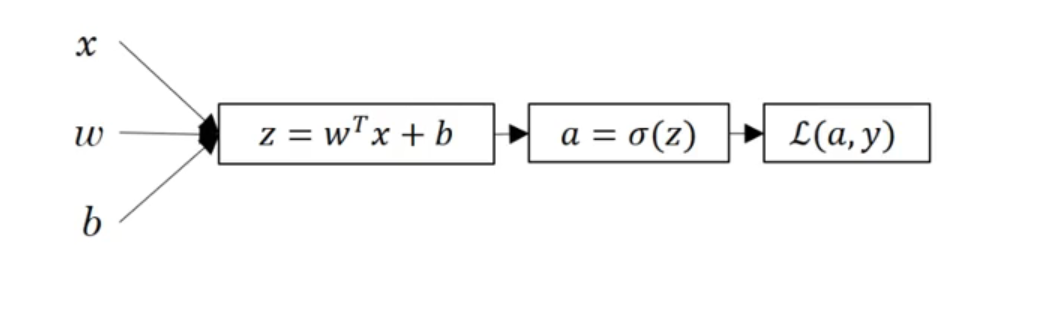